Compute correction for dust extinction due to the extinction within the galaxy (should be a function of inclination).

In [1]:
import numpy as np

from astropy.table import Table, join
from astropy.io import fits
from astropy.coordinates import SkyCoord, Distance
from astropy.cosmology import Planck18
import astropy.constants as const
import astropy.units as u

from hyperfit.linfit import LinFit

import time

import corner

import pickle
from scipy.stats import binned_statistic

import matplotlib.pyplot as plt
#UNCOMMENT FOR 3D PLOTS
# %matplotlib widget

import sys
sys.path.insert(1, '/global/homes/s/sgmoore1/DESI_SGA/TF/')
from TF_photoCorrect import BASS_corr, MW_dust, k_corr, internal_dust

In [2]:
c = const.c.to('km/s')

q0 = 0.2

# Data

## Galaxies

In [3]:
# gals_directory = '/global/cfs/cdirs/desi/science/td/pv/tfgalaxies/Y3/'
gals_directory = ''
gals_filename = '/global/homes/s/sgmoore1/DESI_SGA/TF/Y3/vrot_cats/SGA-2020_loa_Vrot_v5.fits'

gals = Table.read(gals_directory + gals_filename)

In [4]:
# # ###### add the PHOTOSYS row to the table
# tjura = Table.read('/global/cfs/cdirs/desi/science/td/pv/tfgalaxies/Y3/desi_pv_jura_healpix.fits')

# gals['PHOTSYS'] =np.nan
# gals['PHOTSYS'] = gals['PHOTSYS'].astype(np.bytes_)

# i=0
# while i < len(gals):
#     value = tjura[gals['SGA_ID'][i] == tjura['SGA_ID']] 
#     gals['PHOTSYS'][i] = value['PHOTSYS'][0]
#     i+=1

# # # gals.write('/global/cfs/cdirs/desi/science/td/pv/tfgalaxies/Y3/SGA-2020_jura_Vrot_VI.fits', overwrite=True)

In [4]:
gals[:5]

SGA_ID,SGA_GALAXY,GALAXY,PGC,RA_LEDA,DEC_LEDA,MORPHTYPE,PA_LEDA,D25_LEDA,BA_LEDA,Z_LEDA,SB_D25_LEDA,MAG_LEDA,BYHAND,REF,GROUP_ID,GROUP_NAME,GROUP_MULT,GROUP_PRIMARY,GROUP_RA,GROUP_DEC,GROUP_DIAMETER,BRICKNAME,RA,DEC,D26,D26_REF,PA,BA,RA_MOMENT,DEC_MOMENT,SMA_MOMENT,G_SMA50,R_SMA50,Z_SMA50,SMA_SB22,SMA_SB22.5,SMA_SB23,SMA_SB23.5,SMA_SB24,SMA_SB24.5,SMA_SB25,SMA_SB25.5,SMA_SB26,G_MAG_SB22,R_MAG_SB22,Z_MAG_SB22,G_MAG_SB22.5,R_MAG_SB22.5,Z_MAG_SB22.5,G_MAG_SB23,R_MAG_SB23,Z_MAG_SB23,G_MAG_SB23.5,R_MAG_SB23.5,Z_MAG_SB23.5,G_MAG_SB24,R_MAG_SB24,Z_MAG_SB24,G_MAG_SB24.5,R_MAG_SB24.5,Z_MAG_SB24.5,G_MAG_SB25,R_MAG_SB25,Z_MAG_SB25,G_MAG_SB25.5,R_MAG_SB25.5,Z_MAG_SB25.5,G_MAG_SB26,R_MAG_SB26,Z_MAG_SB26,SMA_SB22_ERR,SMA_SB22.5_ERR,SMA_SB23_ERR,SMA_SB23.5_ERR,SMA_SB24_ERR,SMA_SB24.5_ERR,SMA_SB25_ERR,SMA_SB25.5_ERR,SMA_SB26_ERR,G_MAG_SB22_ERR,R_MAG_SB22_ERR,Z_MAG_SB22_ERR,G_MAG_SB22.5_ERR,R_MAG_SB22.5_ERR,Z_MAG_SB22.5_ERR,G_MAG_SB23_ERR,R_MAG_SB23_ERR,Z_MAG_SB23_ERR,G_MAG_SB23.5_ERR,R_MAG_SB23.5_ERR,Z_MAG_SB23.5_ERR,G_MAG_SB24_ERR,R_MAG_SB24_ERR,Z_MAG_SB24_ERR,G_MAG_SB24.5_ERR,R_MAG_SB24.5_ERR,Z_MAG_SB24.5_ERR,G_MAG_SB25_ERR,R_MAG_SB25_ERR,Z_MAG_SB25_ERR,G_MAG_SB25.5_ERR,R_MAG_SB25.5_ERR,Z_MAG_SB25.5_ERR,G_MAG_SB26_ERR,R_MAG_SB26_ERR,Z_MAG_SB26_ERR,G_COG_PARAMS_MTOT,G_COG_PARAMS_M0,G_COG_PARAMS_ALPHA1,G_COG_PARAMS_ALPHA2,G_COG_PARAMS_CHI2,R_COG_PARAMS_MTOT,R_COG_PARAMS_M0,R_COG_PARAMS_ALPHA1,R_COG_PARAMS_ALPHA2,R_COG_PARAMS_CHI2,Z_COG_PARAMS_MTOT,Z_COG_PARAMS_M0,Z_COG_PARAMS_ALPHA1,Z_COG_PARAMS_ALPHA2,Z_COG_PARAMS_CHI2,ELLIPSEBIT,Z_DESI,ZERR_DESI,PHOTSYS,V_0p4R26,V_0p4R26_ERR,LOGVROT,LOGVROT_ERR,logV_SBcorr,logV_correction_factor,logV_SBcorr_err
int64,bytes16,bytes29,int64,float64,float64,bytes21,float32,float32,float32,float32,float32,float32,bool,bytes13,int64,bytes35,int16,bool,float64,float64,float32,bytes8,float64,float64,float32,bytes4,float32,float32,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int32,float64,float64,bytes1,float64,float64,float64,float64,float64,float64,float64
20,SGA-2020 20,SDSSJ173412.71+572041.6,3331584,263.5529355,57.34490699999999,S?,152.58,0.4487454,0.5333349,0.08364453,24.92448,18.036,False,LEDA-20181114,5,SDSSJ173412.71+572041.6,1,True,263.5529355,57.34490699999999,0.4487454,2635p572,263.55294849855886,57.344862145664294,0.4460123,SB26,152.3756,0.5778338,263.5528114673963,57.34481025685253,10.459747,5.9780583,5.751067,4.821581,1.4858595,3.4448266,5.1149526,6.748707,8.426254,9.720271,11.022999,12.0887985,13.380368,20.656942,20.044735,19.40886,19.194794,18.66572,18.231262,18.599888,18.123905,17.745926,18.256256,17.807074,17.476473,18.040592,17.60353,17.319197,17.926336,17.500519,17.228865,17.85259,17.42695,17.180876,17.811844,17.39206,17.151228,17.783718,17.36542,17.143204,0.02069058,0.026094317,0.03480586,0.05076174,0.08751116,0.10309491,0.08337893,0.10982923,0.13734566,0.031223593,0.046367057,0.0777883,0.015935475,0.020728666,0.032657374,0.012760426,0.014699919,0.022893604,0.010505663,0.011998588,0.018923525,0.010358521,0.011374098,0.017719442,0.010557283,0.0112259,0.017149422,0.010553381,0.011049819,0.017135512,0.010413324,0.010993488,0.01699026,0.010291049,0.010862263,0.017057167,17.6411,0.6362121,0.53480667,2.8045392,1.7123051,17.22401,0.6144014,0.53440714,2.7180903,2.1161501,17.062769,0.44818503,0.43006793,3.1755726,0.9

# Empirical internal dust extinction correction

Can we find (and correct for) any correlation between the axis ratio and the color of the galaxies?

## Calculate the "known" photometric corrections

### Survey offsets

In [5]:
sys_corr, sys_corr_err = BASS_corr(gals['PHOTSYS'])

### Dust corrections

In [6]:
# Import E(B-V) dust map
ebv_directory = '/global/cfs/cdirs/desicollab/users/rongpu/dust/desi_ebv/public_data/maps/'
# ebv_directory = '/Users/kdouglass/Documents/Research/data/DESI/'
ebv_filename = 'desi_dust_gr_512.fits'
ebv_map = Table.read(ebv_directory + ebv_filename)

In [7]:
dust_corr, dust_corr_err = MW_dust(gals['RA'], gals['DEC'], ebv_map)

/global/homes/s/sgmoore1/DESI_SGA/TF/TF_photoCorrect.py:90: UserWarning: Warning: converting a masked element to nan.
  EBV_err[i] = ebv_map['EBV_GR_ERR'][i_ebv]


In [8]:
# Flip NaN values to 0
dust_corr_err[np.isnan(dust_corr_err)] = 0

### $K$-corrections

In [9]:
zg0 = gals['Z_DESI'] >= 0

In [10]:
kcorr_zg0 = k_corr(gals['Z_DESI'][zg0], 
                   [gals['G_MAG_SB26'][zg0], gals['R_MAG_SB26'][zg0], gals['Z_MAG_SB26'][zg0]], 
                   [gals['G_MAG_SB26_ERR'][zg0], gals['R_MAG_SB26_ERR'][zg0], gals['Z_MAG_SB26_ERR'][zg0]],
                  z_corr=0.1)

In [11]:
kcorr = np.zeros((len(gals), 3))
kcorr[zg0] = kcorr_zg0

## Apply "known" corrections

In [12]:
gals['G_MAG_SB26_CORR'] = gals['G_MAG_SB26'] - dust_corr[0] + sys_corr - kcorr[:,0]
gals['R_MAG_SB26_CORR'] = gals['R_MAG_SB26'] - dust_corr[1] + sys_corr - kcorr[:,1]
gals['Z_MAG_SB26_CORR'] = gals['Z_MAG_SB26'] - dust_corr[2] + sys_corr - kcorr[:,2]

# gals['G_MAG_SB26_CORR'] = gals['G_MAG_SB26'] - dust_corr[0] + sys_corr
# gals['R_MAG_SB26_CORR'] = gals['R_MAG_SB26'] - dust_corr[1] + sys_corr
# gals['Z_MAG_SB26_CORR'] = gals['Z_MAG_SB26'] - dust_corr[2] + sys_corr

In [13]:
gals['G_MAG_SB26_ERR_CORR'] = np.sqrt(gals['G_MAG_SB26_ERR']**2 + dust_corr_err[0]**2 + sys_corr_err**2)
gals['R_MAG_SB26_ERR_CORR'] = np.sqrt(gals['R_MAG_SB26_ERR']**2 + dust_corr_err[1]**2 + sys_corr_err**2)
gals['Z_MAG_SB26_ERR_CORR'] = np.sqrt(gals['Z_MAG_SB26_ERR']**2 + dust_corr_err[2]**2 + sys_corr_err**2)

## Convert $R_{26}$ to kpc

In [14]:
dist = Distance(z=np.abs(gals['Z_DESI']), cosmology=Planck18)

In [15]:
rng = np.random.default_rng()

N_samples = 1000

dist_err = np.empty(len(dist))*u.Mpc

for i in range(len(dist_err)):
    
    z_desi_random = rng.normal(np.abs(gals['Z_DESI'][i]), 
                               np.abs(gals['ZERR_DESI'][i]), 
                               N_samples)
    
    d_random = Distance(z=z_desi_random, cosmology=Planck18, allow_negative=True)
    
    dist_err[i] = np.std(d_random)

In [16]:
gals['R26_kpc'] = dist.to('kpc')*np.tan(0.5*gals['D26']*u.arcmin)
gals['R26_kpc_err'] = dist_err.to('kpc')*np.tan(0.5*gals['D26']*u.arcmin)

## Compute Absolute Magnitudes

In [17]:
mu = Planck18.distmod(np.abs(gals['Z_DESI']))

gals['R_ABSMAG_SB26_CORR'] = gals['R_MAG_SB26_CORR'] - mu.value

## Correlation between color and axis ratio?

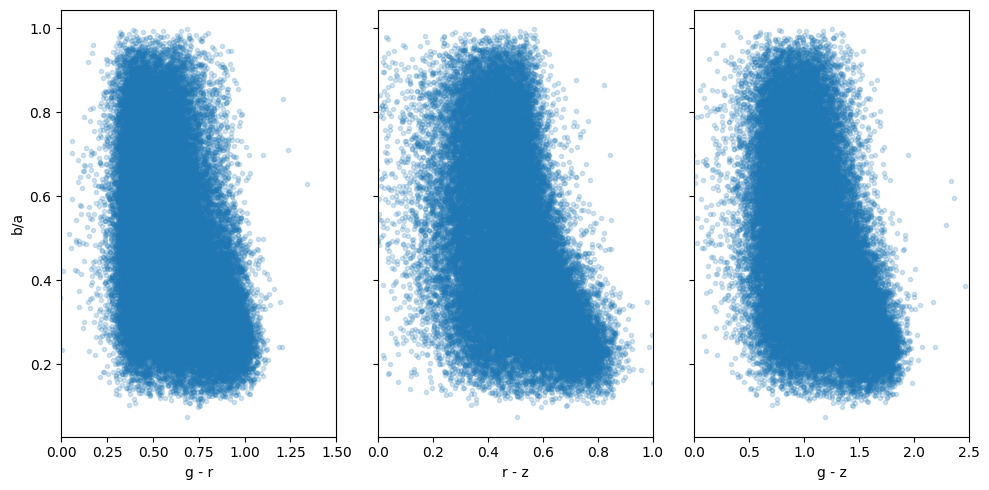

In [18]:
fig, ax = plt.subplots(1, 3, sharey=True, tight_layout=True, figsize=(10,5))

ax[0].plot(gals['G_MAG_SB26_CORR'] - gals['R_MAG_SB26_CORR'], gals['BA'], '.', alpha=0.2)
ax[0].set_xlabel('g - r')
ax[0].set_ylabel('b/a')
ax[0].set_xlim([0, 1.5])

ax[1].plot(gals['R_MAG_SB26_CORR'] - gals['Z_MAG_SB26_CORR'], gals['BA'], '.', alpha=0.2)
ax[1].set_xlabel('r - z')
ax[1].set_xlim([0, 1])

ax[2].plot(gals['G_MAG_SB26_CORR'] - gals['Z_MAG_SB26_CORR'], gals['BA'], '.', alpha=0.2)
ax[2].set_xlabel('g - z')
ax[2].set_xlim([0, 2.5]);

## Correlation between magnitude and axis ratio?

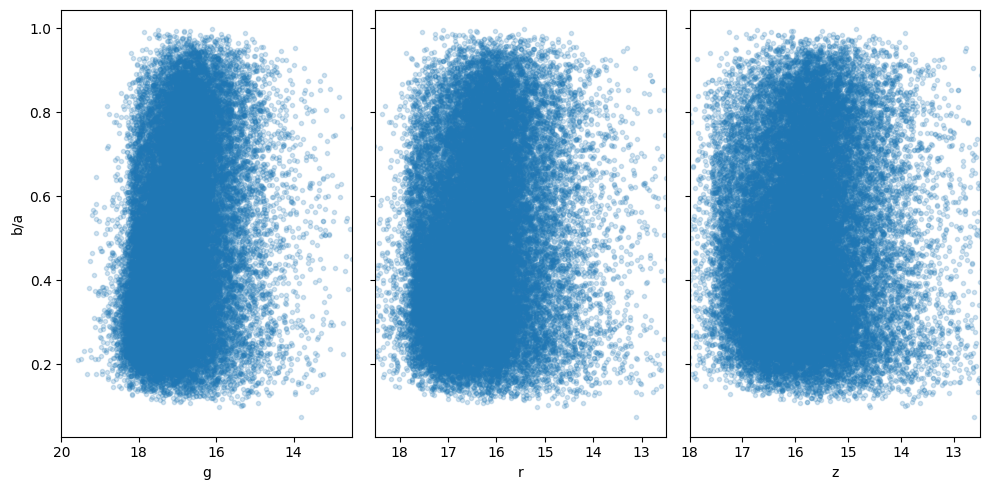

In [19]:
fig, ax = plt.subplots(1, 3, sharey=True, tight_layout=True, figsize=(10,5))

ax[0].plot(gals['G_MAG_SB26_CORR'], gals['BA'], '.', alpha=0.2)
ax[0].set_xlabel('g')
ax[0].set_ylabel('b/a')
ax[0].set_xlim([20, 12.5])

ax[1].plot(gals['R_MAG_SB26_CORR'], gals['BA'], '.', alpha=0.2)
ax[1].set_xlabel('r')
ax[1].set_xlim([18.5, 12.5])

ax[2].plot(gals['Z_MAG_SB26_CORR'], gals['BA'], '.', alpha=0.2)
ax[2].set_xlabel('z')
ax[2].set_xlim([18, 12.5]);

## Correlation between magnitude, $R_{26}$, and axis ratio?

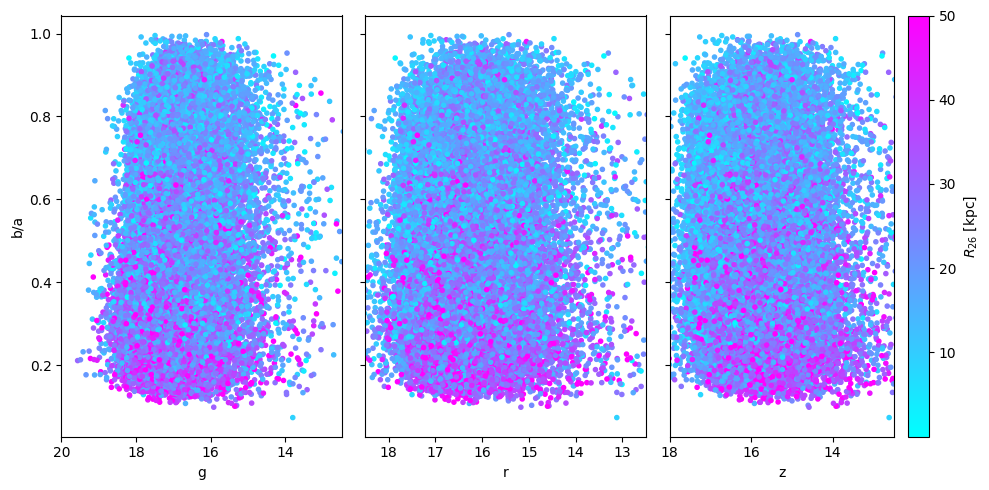

In [20]:
fig, ax = plt.subplots(1, 3, sharey=True, tight_layout=True, figsize=(10,5))

ax[0].scatter(gals['G_MAG_SB26_CORR'], gals['BA'], c=gals['R26_kpc'], marker='.', vmax=50, cmap='cool')
ax[0].set_xlabel('g')
ax[0].set_ylabel('b/a')
ax[0].set_xlim([20, 12.5])

ax[1].scatter(gals['R_MAG_SB26_CORR'], gals['BA'], c=gals['R26_kpc'], marker='.', vmax=50, cmap='cool')
ax[1].set_xlabel('r')
ax[1].set_xlim([18.5, 12.5])

zplot = ax[2].scatter(gals['Z_MAG_SB26_CORR'], gals['BA'], c=gals['R26_kpc'], marker='.', vmax=50, cmap='cool')
ax[2].set_xlabel('z')
ax[2].set_xlim([18, 12.5])

plt.colorbar(zplot, label='$R_{26}$ [kpc]');

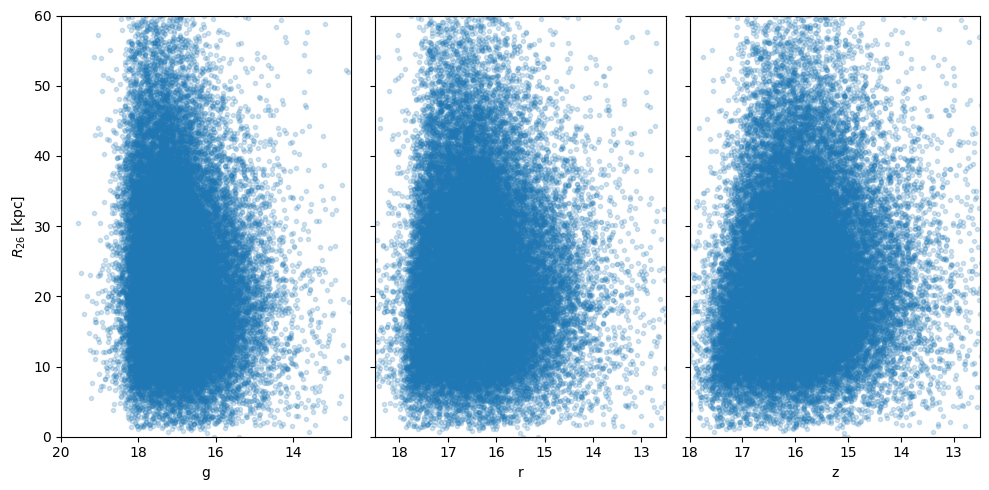

In [21]:
fig, ax = plt.subplots(1, 3, sharey=True, tight_layout=True, figsize=(10,5))

ax[0].plot(gals['G_MAG_SB26_CORR'], gals['R26_kpc'], '.', alpha=0.2)
ax[0].set_xlabel('g')
ax[0].set_ylabel('$R_{26}$ [kpc]')
ax[0].set_xlim([20, 12.5])
ax[0].set_ylim([0, 60])

ax[1].plot(gals['R_MAG_SB26_CORR'], gals['R26_kpc'], '.', alpha=0.2)
ax[1].set_xlabel('r')
ax[1].set_xlim([18.5, 12.5])

ax[2].plot(gals['Z_MAG_SB26_CORR'], gals['R26_kpc'], '.', alpha=0.2)
ax[2].set_xlabel('z')
ax[2].set_xlim([18, 12.5]);

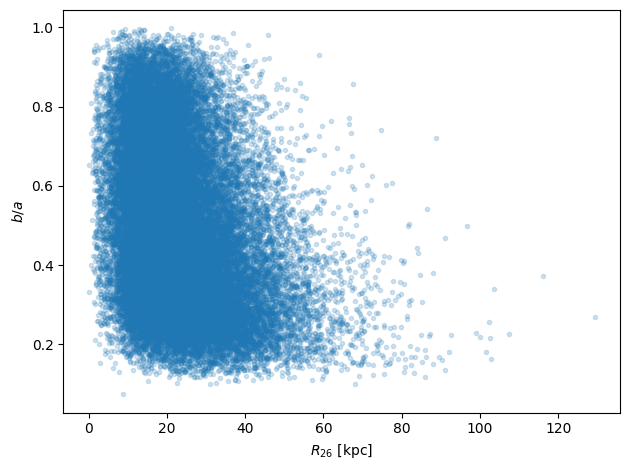

In [22]:
plt.figure(tight_layout=True)

plt.plot(gals['R26_kpc'], gals['BA'], '.', alpha=0.2)

plt.xlabel('$R_{26}$ [kpc]')
plt.ylabel('$b/a$');

## Let's try fitting a line to ($m_r$, $b/a$)

We're going to let $x = b/a$ and $y = m_r$

In [23]:
ba_binwidth=0.1
ba = np.arange(0.1,1,ba_binwidth)

In [24]:
N = len(gals['R_MAG_SB26_CORR'])
N_bins = len(ba)

In [25]:
mr_bins = np.nan*np.ones(len(ba))
Mr_bins = np.nan*np.ones(len(ba))
cov_bins = np.nan*np.ones((2, 2, N_bins))


for i in range(N_bins):
    gals_subset_ba = gals[(gals['BA'] > ba[i]) & (gals['BA'] <= ba[i] + ba_binwidth)]
    if len(gals_subset_ba) > 0:
        mr_bins[i] = np.median(gals_subset_ba['R_MAG_SB26_CORR'])
        Mr_bins[i] = np.median(gals_subset_ba['R_ABSMAG_SB26_CORR'])
        # cov_bins[:,:,i] = np.array([[0., 0.], [0., np.std(gals_subset_ba['R_MAG_SB26_CORR'])**2]])
        # cov_bins[:,:,i] = np.array([[0., 0.], [0., np.mean((gals_subset_ba['R_MAG_SB26_CORR'] - mr_bins[i])**2)/len(gals_subset_ba)]])
        cov_bins[:,:,i] = np.array([[0., 0.], [0., 1/len(gals_subset_ba)]])

In [26]:
# Shift the pivot point (y-intercept) to minimize the correlations between the fit coefficients
mr_median = np.median(gals['R_MAG_SB26_CORR'])
Mr_median = np.median(gals['R_ABSMAG_SB26_CORR'])
print(mr_median, Mr_median)

16.39217633522116 -20.51760053925949


In [27]:
# Create the Hyperfit object
# hf = LinFit([gals['BA'], gals['R_MAG_SB26_CORR'] - mr_median], cov)
hf_bins = LinFit([ba, mr_bins - mr_median], cov_bins)
hf_bins_absmag = LinFit([ba, Mr_bins - Mr_median], cov_bins)

In [43]:
# Set bounds of coefficients
bounds = ((-100.0, 1.0), (-1.0, 10.0), (1.0e-5, 50.))
bounds_absmag = ((-100.0, 1.0), (-30.0, 10.0), (1.0e-5, 50.))

In [29]:
# Run MCMC to fit line
# mcmc_samples, mcmc_lnlike = hf.emcee(bounds, verbose=True)
mcmc_samples, mcmc_lnlike = hf_bins.emcee(bounds, verbose=True)
mcmc_samples_absmag, mcmc_lnlike_absmag = hf_bins_absmag.emcee(bounds_absmag, verbose=True)

 message: Optimization terminated successfully.
 success: True
     fun: -17.711908826303034
       x: [ 1.338e-01  1.901e-01  8.257e-02]
     nit: 60
    nfev: 2781
     jac: [ 9.592e-06 -1.066e-06  2.345e-05]


100%|██████████| 1000/1000 [00:00<00:00, 2086.38it/s]


Niterations/Max Iterations:  1000 / 100000
Integrated ACT/Min Convergence Iterations:  [37.96051242 32.07824764 38.3133718 ] / 1915.6685901281928


100%|██████████| 1000/1000 [00:00<00:00, 2090.16it/s]


Niterations/Max Iterations:  2000 / 100000
Integrated ACT/Min Convergence Iterations:  [47.05380299 44.5685716  33.77703064] / 2352.6901496084342


...

Niterations/Max Iterations:  12000 / 100000
Integrated ACT/Min Convergence Iterations:  [49.22758978 44.76527214 55.42206677] / 2771.1033383059894


100%|██████████| 1000/1000 [00:00<00:00, 2138.57it/s]


Niterations/Max Iterations:  13000 / 100000
Integrated ACT/Min Convergence Iterations:  [48.99690274 47.25228169 54.35818768] / 2717.909384045169


100%|██████████| 1000/1000 [00:00<00:00, 2161.80it/s]


Niterations/Max Iterations:  14000 / 100000
Integrated ACT/Min Convergence Iterations:  [49.19493983 46.58878487 53.01875048] / 2650.937524031429


In [30]:
# Calculate parameter values and covariance matrix
A_ba, B, sig = np.median(mcmc_samples, axis=1)
A_ba_absmag, B_absmag, sig_absmag = np.median(mcmc_samples_absmag, axis=1)
'''
cov_fit = np.cov(mcmc_samples)
A_ba_err = np.sqrt(cov_fit[0,0])
B_err = np.sqrt(cov_fit[1,1])
'''
A_ba_err = np.std(mcmc_samples[0][(-1.5 < mcmc_samples[0]) & (mcmc_samples[0] < 0)])
B_err = np.std(mcmc_samples[1][(0 < mcmc_samples[1]) & (mcmc_samples[1] < 1)])
A_ba_absmag_err = np.std(mcmc_samples_absmag[0][(-1.5 < mcmc_samples_absmag[0]) & (mcmc_samples_absmag[0] < 0)])
B_absmag_err = np.std(mcmc_samples_absmag[1][(0 < mcmc_samples_absmag[1]) & (mcmc_samples_absmag[1] < 1)])
'''
A_ba_err = np.quantile(mcmc_samples[0], [0.16, 0.5, 0.84])
B_err = np.quantile(mcmc_samples[1], [0.16, 0.5, 0.84])
'''
print(f'{A_ba:.2f} +/- {A_ba_err:.2f}')
print(f' {B:.2f} +/- {B_err:.2f}')
print(f'{A_ba_absmag:.2f} +/- {A_ba_absmag_err:.2f}')
print(f' {B_absmag:.2f} +/- {B_absmag_err:.2f}')

-0.75 +/- 0.20
 0.31 +/- 0.12
-0.74 +/- 0.15
 0.35 +/- 0.08


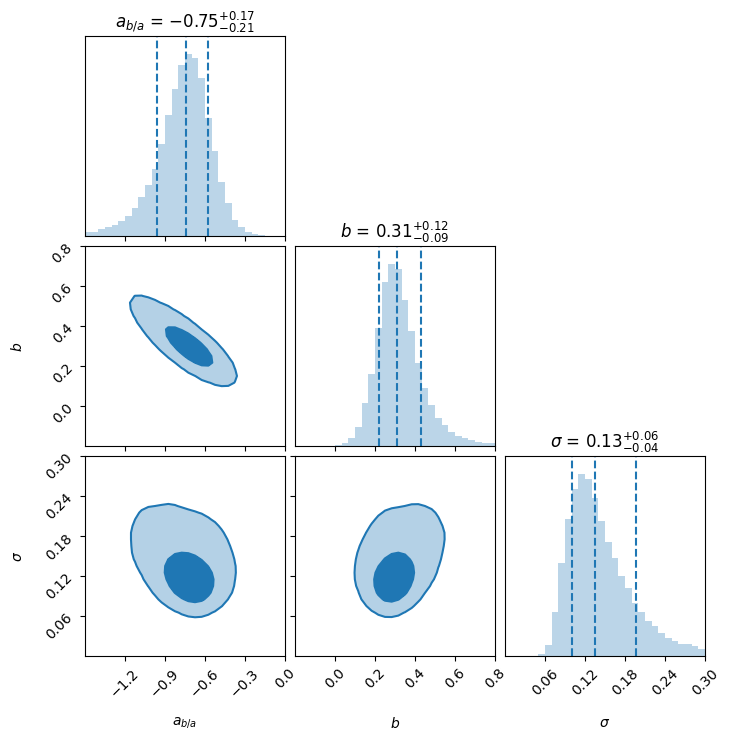

In [31]:
fig = corner.corner(mcmc_samples.T, 
                    bins=30, 
                    smooth=1, 
                    range=[[-1.5, 0], [-0.2, 0.8], [0, 0.3]],
                    # range=[[-6, 6], [-3, 3], [-3, 3]],
                    labels=['$a_{b/a}$', '$b$', r'$\sigma$'], 
                    levels=(1-np.exp(-0.5), 1-np.exp(-2)), 
                    quantiles=[0.16, 0.5, 0.84], 
                    color='tab:blue', 
                    hist_kwargs={'histtype':'stepfilled', 'alpha':0.3}, 
                    plot_datapoints=False,
                    fill_contours=True, 
                    show_titles=True);

# fig = corner.corner(mcmc_samples_absmag.T, 
#                     bins=30, 
#                     smooth=1, 
#                     range=[[-1.5, 0], [-0.2, 0.8], [0, 0.3]],
#                     # range=[[-6, 6], [-3, 3], [-3, 3]],
#                     labels=['$a_{b/a}$', '$b$', r'$\sigma$'], 
#                     levels=(1-np.exp(-0.5), 1-np.exp(-2)), 
#                     quantiles=[0.16, 0.5, 0.84], 
#                     color='tab:blue', 
#                     hist_kwargs={'histtype':'stepfilled', 'alpha':0.3}, 
#                     plot_datapoints=False,
#                     fill_contours=True, 
#                     show_titles=True);

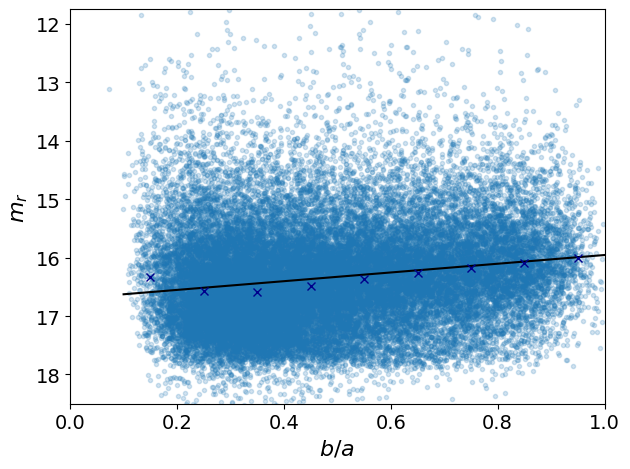

In [32]:
plt.figure(tight_layout=True)

plt.plot(gals['BA'], gals['R_MAG_SB26_CORR'], '.', alpha=0.2)
# plt.errorbar(ba, mr_bins, yerr=np.sqrt(cov_bins[1,1,:]), fmt='x', c='tab:blue')
plt.errorbar(ba + 0.05, mr_bins, yerr=np.sqrt(cov_bins[1,1,:]), fmt='x', c='darkblue')

plt.plot([0.1, 1], A_ba*np.array([0.1, 1]) + (B + mr_median), 'k')

plt.xlim([0, 1])
plt.ylim([18.5, 11.75])

plt.tick_params('both', which='major', labelsize=14)

plt.xlabel('$b/a$', fontsize=16)
plt.ylabel('$m_r$', fontsize=16);

# plt.savefig('/pscratch/sd/s/sgmoore1/TF/figures/loa_internalDustCorr.png', dpi=150, facecolor='none');

### Save MCMC chains

In [35]:
# # temp_outfile = open('/pscratch/sd/s/sgmoore1/TF/pickles/loa_internalDust_z0p1_mcmc.pickle', 'wb')
# temp_outfile = open('/pscratch/sd/s/sgmoore1/TF/pickles/loa_internalDust_nokcorr_mcmc.pickle', 'wb')
# pickle.dump((mcmc_samples, mr_median), temp_outfile)
# temp_outfile.close()

## Apply the Correction

In [33]:
internalDust_corr, internalDust_corr_err = internal_dust(gals['BA'], 
                                                         [A_ba, B], 
                                                         [A_ba_err, B_err])

r_mag_sb26_corr = gals['R_MAG_SB26_CORR'] - internalDust_corr
r_mag_sb26_corr_err = np.sqrt(gals['R_MAG_SB26_ERR_CORR']**2 + internalDust_corr_err**2)

In [34]:
A_ba

-0.7459440917901585

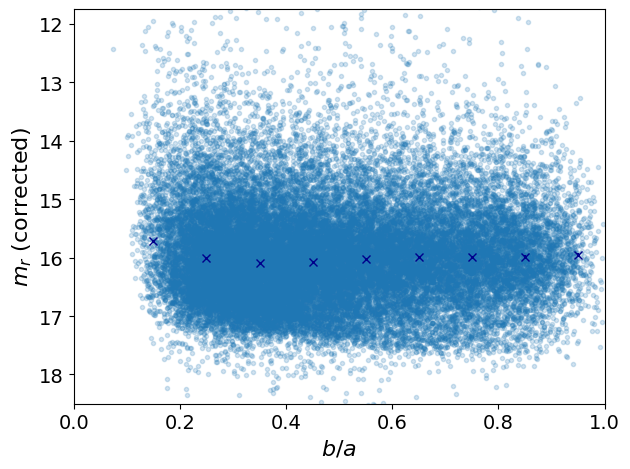

In [35]:
##### check if it removed the correlation:

mr_bins_updated = np.nan*np.ones(len(ba))
cov_bins_updated = np.nan*np.ones((2, 2, N_bins))

for i in range(N_bins):
    ba_subset = (gals['BA'] > ba[i]) & (gals['BA'] <= ba[i]+0.1)
    if sum(ba_subset) > 0:
        mr_bins_updated[i] = np.median(r_mag_sb26_corr[ba_subset])
        cov_bins_updated[:,:,i] = np.array([[0., 0.], [0., 1/sum(ba_subset)]])


plt.figure(tight_layout=True)

plt.plot(gals['BA'], r_mag_sb26_corr, '.', alpha=0.2)
# plt.errorbar(ba, mr_bins, yerr=np.sqrt(cov_bins[1,1,:]), fmt='x', c='tab:blue')
plt.errorbar(ba + 0.05, mr_bins_updated, yerr=np.sqrt(cov_bins_updated[1,1,:]), fmt='x', c='darkblue')

plt.xlim([0, 1])
plt.ylim([18.5, 11.75])

plt.tick_params('both', which='major', labelsize=14)

plt.xlabel('$b/a$', fontsize=16)
plt.ylabel('$m_r$ (corrected)', fontsize=16);

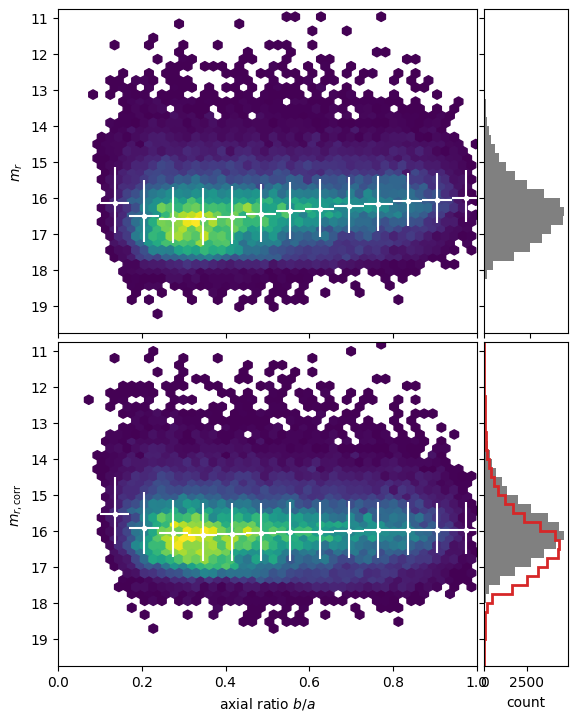

In [36]:
fig, axes = plt.subplots(2,2, figsize=(6,7.5),
                         gridspec_kw={'hspace':0.03, 'wspace':0.0295, 'width_ratios':[5,1]})

# m_r_bins = np.arange(19.75, 10.5, -0.25)
m_r_bins = np.arange(10.75, 20, 0.25)
ba_bins = np.arange(0.1, 1.05, 0.07)
ba = 0.5*(ba_bins[1:] + ba_bins[:-1])
ba_err = 0.5*np.diff(ba_bins)
m_r_median = np.median(gals['R_MAG_SB26_CORR'])
m_r, _, _ = binned_statistic(gals['BA'], gals['R_MAG_SB26_CORR'], statistic='median', bins=ba_bins)
n_bin, _, _ = binned_statistic(gals['BA'], gals['R_MAG_SB26_CORR'], statistic='count', bins=ba_bins)
m_r_err, _, _ = binned_statistic(gals['BA'], gals['R_MAG_SB26_CORR'], statistic='std', bins=ba_bins)
m_r_err_lo, _, _ = binned_statistic(gals['BA'], gals['R_MAG_SB26_CORR'], statistic=lambda x: np.percentile(x, [16]), bins=ba_bins)
m_r_err_hi, _, _ = binned_statistic(gals['BA'], gals['R_MAG_SB26_CORR'], statistic=lambda x: np.percentile(x, [84]), bins=ba_bins)
# m_r_err /= np.sqrt(n_bin)

ax = axes[0,0]
ax.hexbin(gals['BA'], gals['R_MAG_SB26_CORR'], gridsize=(45,30), cmap='viridis', mincnt=1)
ax.errorbar(ba, m_r, xerr=ba_err, yerr=[m_r - m_r_err_lo, m_r_err_hi - m_r], fmt='.', color='white')

ax.set(xlim=(0,1),
       ylim=(19.75,10.75),
       ylabel=r'$m_r$',
       xticklabels=[])

ax = axes[0,1]
ax.hist(gals['R_MAG_SB26_CORR'], bins=m_r_bins, orientation='horizontal', color='gray')
ax.set(ylim=(19.75,10.75),
       yticklabels=[],
       xticklabels=[])

m_r, _, _ = binned_statistic(gals['BA'], gals['R_MAG_SB26_CORR']  - internalDust_corr, statistic='median', bins=ba_bins)
n_bin, _, _ = binned_statistic(gals['BA'], gals['R_MAG_SB26_CORR']  - internalDust_corr, statistic='count', bins=ba_bins)
m_r_err, _, _ = binned_statistic(gals['BA'], gals['R_MAG_SB26_CORR']  - internalDust_corr, statistic='std', bins=ba_bins)
m_r_err_lo, _, _ = binned_statistic(gals['BA'], gals['R_MAG_SB26_CORR']  - internalDust_corr, statistic=lambda x: np.percentile(x, [16]), bins=ba_bins)
m_r_err_hi, _, _ = binned_statistic(gals['BA'], gals['R_MAG_SB26_CORR']  - internalDust_corr, statistic=lambda x: np.percentile(x, [84]), bins=ba_bins)

ax = axes[1,0]
ax.hexbin(gals['BA'], gals['R_MAG_SB26_CORR'] - internalDust_corr, gridsize=(45,30), cmap='viridis', mincnt=1)
ax.errorbar(ba, m_r, xerr=ba_err, yerr=[m_r - m_r_err_lo, m_r_err_hi - m_r], fmt='.', color='white')

ax.set(xlim=(0,1),
       ylim=(19.75,10.75),
       xlabel=r'axial ratio $b/a$',
       ylabel=r'$m_{r,\mathrm{corr}}$')

ax = axes[1,1]
ax.hist(gals['R_MAG_SB26_CORR'] - internalDust_corr, bins=m_r_bins, orientation='horizontal', color='gray')
ax.hist(gals['R_MAG_SB26_CORR'], bins=m_r_bins, orientation='horizontal', histtype='step', lw=2, color='tab:red')
ax.set(ylim=(19.75,10.75),
       yticklabels=[],
       xlabel='count')

fig.subplots_adjust(left=0.1, right=0.95, top=0.95, bottom=0.075)
# fig.savefig('/pscratch/sd/s/sgmoore1/TF/figures/loa_internalDustCorr_hexbin.png', dpi=150, facecolor='none');

## Now repeat using the magnitudes in the g and z bands

In [44]:
ba_binwidth=0.1
ba = np.arange(0.1,1,ba_binwidth)

In [45]:
mg_bins = np.nan*np.ones(len(ba))
mz_bins = np.nan*np.ones(len(ba))

for i in range(N_bins):
    gals_subset_ba = gals[(gals['BA'] > ba[i]) & (gals['BA'] <= ba[i]+0.1)]
    if len(gals_subset_ba) > 0:
        mg_bins[i] = np.median(gals_subset_ba['G_MAG_SB26_CORR'])
        mz_bins[i] = np.median(gals_subset_ba['Z_MAG_SB26_CORR'])

In [46]:
# Shift the pivot point (y-intercept) to minimize the correlations between the fit coefficients
mz_median = np.median(gals['Z_MAG_SB26_CORR'])
mg_median = np.median(gals['G_MAG_SB26_CORR'])
print(mz_median, mg_median)

15.887544531434216 17.02022658305615


In [47]:
# Create the Hyperfit objects
zhf_bins = LinFit([ba, mz_bins - mz_median], cov_bins)
ghf_bins = LinFit([ba, mg_bins - mg_median], cov_bins)

In [48]:
# Run MCMC to fit lines
z_mcmc_samples, z_mcmc_lnlike = zhf_bins.emcee(bounds, verbose=True)
g_mcmc_samples, g_mcmc_lnlike = ghf_bins.emcee(bounds, verbose=True)

 message: Optimization terminated successfully.
 success: True
     fun: -15.55016439142287
       x: [ 5.134e-02  1.220e-01  1.055e-01]
     nit: 66
    nfev: 3031
     jac: [ 1.189e-03  8.712e-03 -1.167e-02]


100%|██████████| 1000/1000 [00:00<00:00, 2143.76it/s]


Niterations/Max Iterations:  1000 / 100000
Integrated ACT/Min Convergence Iterations:  [48.83139358 42.74505138 39.86970674] / 2441.569678879514


100%|██████████| 1000/1000 [00:00<00:00, 2143.30it/s]


Niterations/Max Iterations:  2000 / 100000
Integrated ACT/Min Convergence Iterations:  [74.8611635 65.4753518 50.0202602] / 3743.0581750205697


...

Niterations/Max Iterations:  5000 / 100000
Integrated ACT/Min Convergence Iterations:  [52.36540308 42.00273359 41.96148969] / 2618.270154174789


100%|██████████| 1000/1000 [00:00<00:00, 2162.37it/s]


Niterations/Max Iterations:  6000 / 100000
Integrated ACT/Min Convergence Iterations:  [49.99441996 39.85520795 43.99367608] / 2499.7209977936727


100%|██████████| 1000/1000 [00:00<00:00, 2161.83it/s]

Niterations/Max Iterations:  7000 / 100000
Integrated ACT/Min Convergence Iterations:  [48.57089911 39.81094805 42.40747725] / 2428.5449552674836


In [49]:
# Calculate parameter values and covariance matrix
Az_ba, Bz, sigz = np.median(z_mcmc_samples, axis=1)
Ag_ba, Bg, sigg = np.median(g_mcmc_samples, axis=1)

Az_ba_err = np.std(z_mcmc_samples[0][(-1.5 < z_mcmc_samples[0]) & (z_mcmc_samples[0] < 0)])
Bz_err = np.std(z_mcmc_samples[1][(0 < z_mcmc_samples[1]) & (z_mcmc_samples[1] < 1)])

Ag_ba_err = np.std(g_mcmc_samples[0][(-1.75 < g_mcmc_samples[0]) & (g_mcmc_samples[0] < -0.5)])
Bg_err = np.std(g_mcmc_samples[1][(0 < g_mcmc_samples[1]) & (g_mcmc_samples[1] < 1)])

print(f'{Az_ba:.2f} +/- {Az_ba_err:.2f}')
print(f' {Bz:.2f} +/- {Bz_err:.2f}')
print(f'{Ag_ba:.2f} +/- {Ag_ba_err:.2f}')
print(f' {Bg:.2f} +/- {Bg_err:.2f}')

-0.54 +/- 0.26
 0.22 +/- 0.15
-1.02 +/- 0.21
 0.43 +/- 0.13


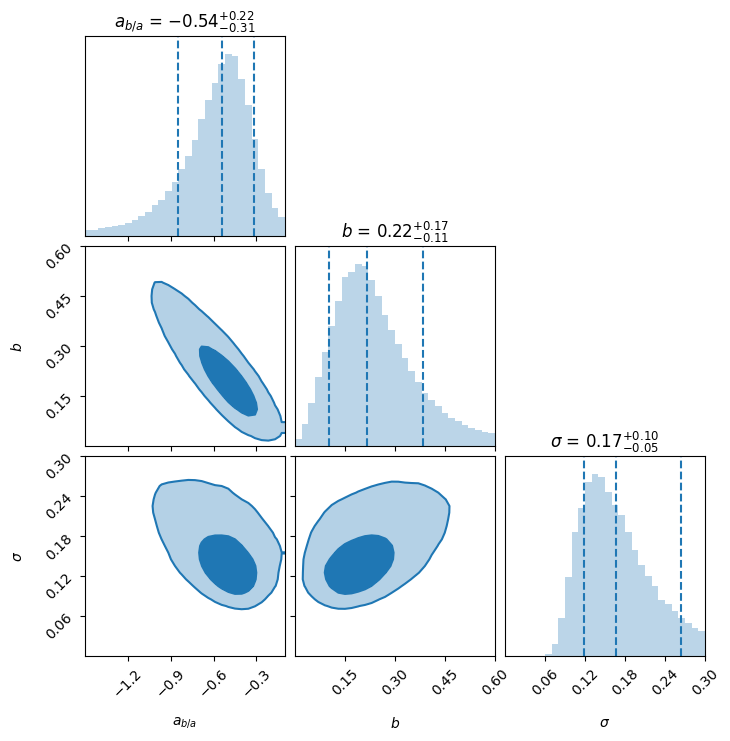

In [50]:
fig = corner.corner(z_mcmc_samples.T, 
                    bins=30, 
                    smooth=1, 
                    range=[[-1.5, -0.1], [0, 0.6], [0, 0.3]],
                    # range=[[-6, 6], [-3, 3], [0, 3]],
                    labels=['$a_{b/a}$', '$b$', r'$\sigma$'], 
                    levels=(1-np.exp(-0.5), 1-np.exp(-2)), 
                    quantiles=[0.16, 0.5, 0.84], 
                    color='tab:blue', 
                    hist_kwargs={'histtype':'stepfilled', 'alpha':0.3}, 
                    plot_datapoints=False,
                    fill_contours=True, 
                    show_titles=True);

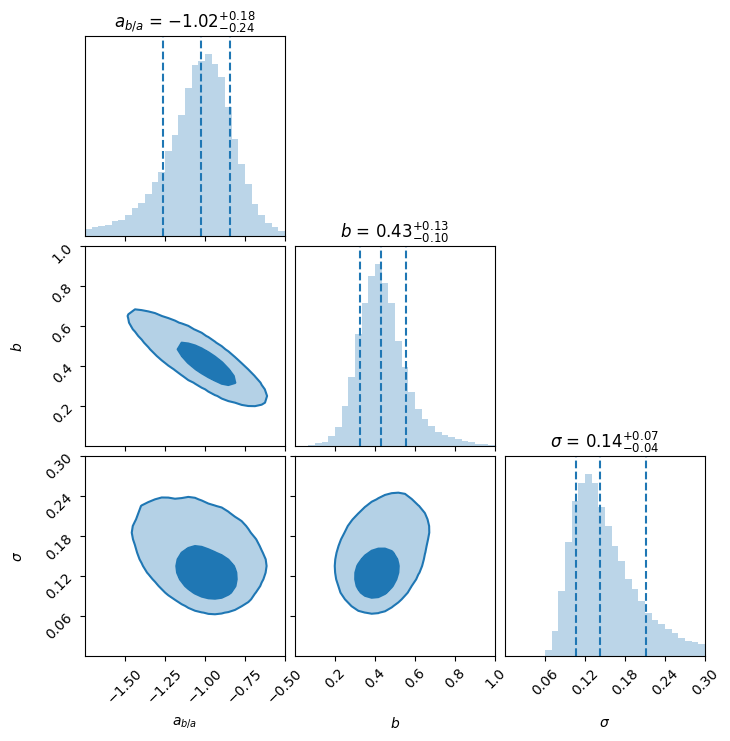

In [51]:
fig = corner.corner(g_mcmc_samples.T, 
                    bins=30, 
                    smooth=1, 
                    range=[[-1.75, -0.5], [0, 1], [0, 0.3]],
                    # range=[[-6, 6], [-3, 3], [0, 3]],
                    labels=['$a_{b/a}$', '$b$', r'$\sigma$'], 
                    levels=(1-np.exp(-0.5), 1-np.exp(-2)), 
                    quantiles=[0.16, 0.5, 0.84], 
                    color='tab:blue', 
                    hist_kwargs={'histtype':'stepfilled', 'alpha':0.3}, 
                    plot_datapoints=False,
                    fill_contours=True, 
                    show_titles=True);

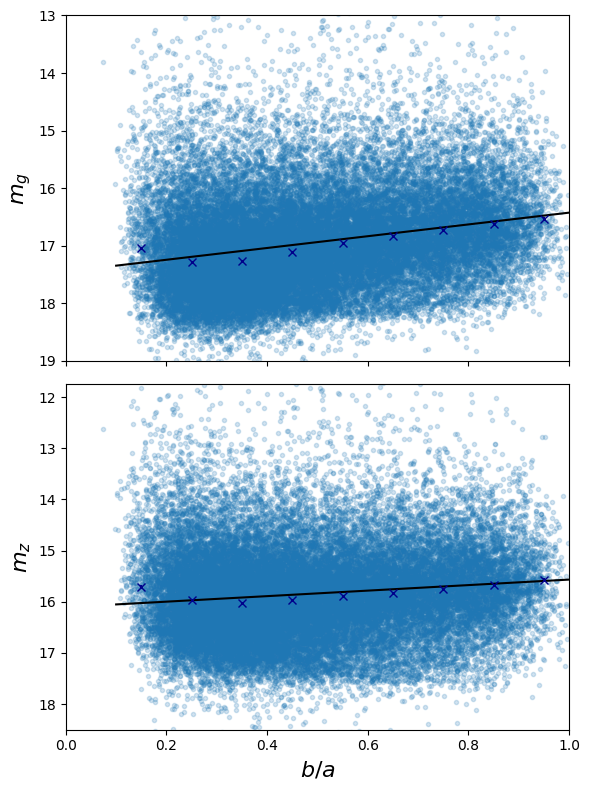

In [52]:
fig, axes = plt.subplots(2,1, figsize=(6,8), sharex=True, sharey=False, tight_layout=True)


ax = axes[0]
ax.plot(gals['BA'], gals['G_MAG_SB26_CORR'], '.', alpha=0.2)
ax.errorbar(ba + 0.05, mg_bins, yerr=np.sqrt(cov_bins[1,1,:]), fmt='x', c='darkblue')

ax.plot([0.1, 1], Ag_ba*np.array([0.1, 1]) + (Bg + mg_median), 'k')

ax.set_xlim([0, 1])
ax.set_ylim([19, 13])

# ax.set_tick_params('both', which='major', labelsize=14)

ax.set_ylabel('$m_g$', fontsize=16)


ax = axes[1]
ax.plot(gals['BA'], gals['Z_MAG_SB26_CORR'], '.', alpha=0.2)
ax.errorbar(ba + 0.05, mz_bins, yerr=np.sqrt(cov_bins[1,1,:]), fmt='x', c='darkblue')

ax.plot([0.1, 1], Az_ba*np.array([0.1, 1]) + (Bz + mz_median), 'k')

ax.set_ylim([18.5, 11.75])

# ax.set_tick_params('both', which='major', labelsize=14)

ax.set_xlabel('$b/a$', fontsize=16)
ax.set_ylabel('$m_z$', fontsize=16);


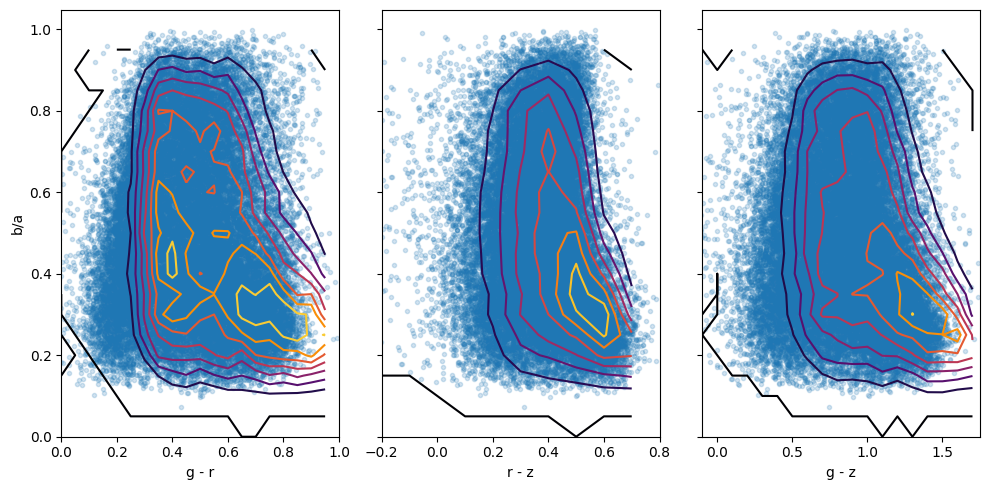

In [53]:
#### See if this correlation got fixed:

internalDust_corr, internalDust_corr_err = internal_dust(gals['BA'], 
                                                         [Az_ba, Bz], 
                                                         [Az_ba_err, Bz_err])

z_mag_sb26_corr = gals['Z_MAG_SB26_CORR'] - internalDust_corr
z_mag_sb26_corr_err = np.sqrt(gals['Z_MAG_SB26_ERR_CORR']**2 + internalDust_corr_err**2)


internalDust_corr, internalDust_corr_err = internal_dust(gals['BA'], 
                                                         [Ag_ba, Bg], 
                                                         [Ag_ba_err, Bg_err])

g_mag_sb26_corr = gals['G_MAG_SB26_CORR'] - internalDust_corr
g_mag_sb26_corr_err = np.sqrt(gals['G_MAG_SB26_ERR_CORR']**2 + internalDust_corr_err**2)

fig, ax = plt.subplots(1, 3, sharey=True, tight_layout=True, figsize=(10,5))

counts, xbins, ybins = np.histogram2d(gals['G_MAG_SB26_CORR'] - gals['R_MAG_SB26_CORR'], 
                                      gals['BA'], 
                                      bins=[np.arange(0,1.05,0.05), np.arange(0,1.05,0.05)])
ax[0].plot(g_mag_sb26_corr - r_mag_sb26_corr, gals['BA'], '.', alpha=0.2)
ax[0].contour(xbins[:-1], ybins[:-1], counts.T, cmap='inferno')
ax[0].set_xlabel('g - r')
ax[0].set_ylabel('b/a')
ax[0].set_xlim([0, 1])

counts, xbins, ybins = np.histogram2d(gals['R_MAG_SB26_CORR'] - gals['Z_MAG_SB26_CORR'], 
                                      gals['BA'], 
                                      bins=[np.arange(-0.2,0.9,0.1), np.arange(0,1.05,0.05)])
ax[1].plot(r_mag_sb26_corr - z_mag_sb26_corr, gals['BA'], '.', alpha=0.2)
ax[1].contour(xbins[:-1], ybins[:-1], counts.T, cmap='inferno')
ax[1].set_xlabel('r - z')
ax[1].set_xlim([-0.2, 0.8])

counts, xbins, ybins = np.histogram2d(gals['G_MAG_SB26_CORR'] - gals['Z_MAG_SB26_CORR'], 
                                      gals['BA'], 
                                      bins=[np.arange(-0.1,1.85,0.1), np.arange(0,1.05,0.05)])
ax[2].plot(g_mag_sb26_corr - z_mag_sb26_corr, gals['BA'], '.', alpha=0.2)
ax[2].contour(xbins[:-1], ybins[:-1], counts.T, cmap='inferno')
ax[2].set_xlabel('g - z')
ax[2].set_xlim([-0.1, 1.75]);

In [54]:
temp_outfile = open('/pscratch/sd/s/sgmoore1/TF/pickles/loa_internalDust_z0p1_mcmc.pickle', 'wb')
# temp_outfile = open('/pscratch/sd/s/sgmoore1/TF/pickles/loa_internalDust_nokcorr_mcmc.pickle', 'wb')
pickle.dump((mcmc_samples, mr_median, g_mcmc_samples, mg_median, z_mcmc_samples, mz_median), temp_outfile)
temp_outfile.close()